In [43]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
# Load raw data
df_sorted = pd.read_excel('/content/df_sorted.xlsx')
df_trade = pd.read_excel("/content/trade_2002_2019.xlsx")

Final W matrix dimension: (11, 11)


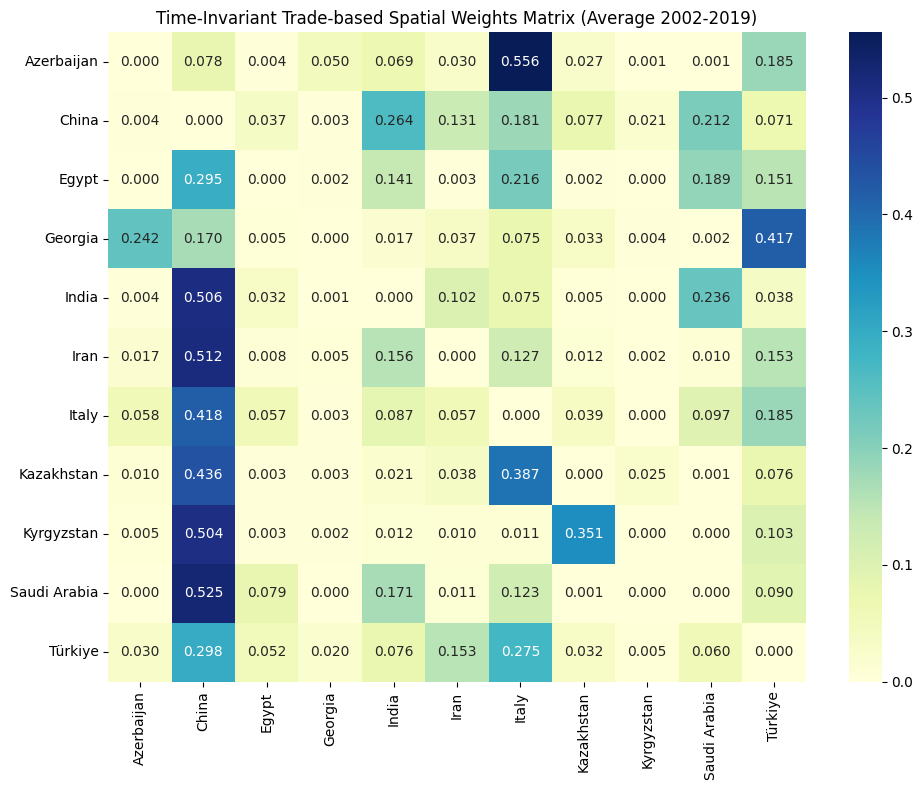

In [52]:
# Keep only the trade flows of interest (exports 'X' and imports 'M')
df_trade = df_trade[df_trade['flowCode'].isin(['X', 'M'])].copy()

# Harmonize column names
df_trade.rename(columns={
    'refYear': 'year',
    'reporterDesc': 'from',
    'partnerDesc': 'to',
    'primaryValue': 'value'
}, inplace=True)

# Filter to the set of countries included in the analysis
selected_countries = [
    "Azerbaijan",
    "China",
    "Egypt",
    "Georgia",
    "India",
    "Iran",
    "Italy",
    "Kazakhstan",
    "Kyrgyzstan",
    "Saudi Arabia",
    "Türkiye"
]
df_trade = df_trade[df_trade['from'].isin(selected_countries) & df_trade['to'].isin(selected_countries)]

# Build the country index
countries = sorted(list(set(df_trade['from']).union(df_trade['to'])))
country_to_idx = {country: i for i, country in enumerate(countries)}
n = len(countries)  # N = 11

# --- Step 1: Compute the average bilateral trade value over the period ---

# Compute mean bilateral trade (from "from" to "to") over all years
df_avg = df_trade.groupby(['from', 'to'])['value'].mean().reset_index()

# --- Step 2: Construct the spatial weight matrix (W) based on average trade ---

# Raw (unnormalized) weight matrix
W_raw_avg = np.zeros((n, n))

# Fill the matrix with average bilateral trade values
for _, row in df_avg.iterrows():
    i = country_to_idx[row['from']]
    j = country_to_idx[row['to']]
    W_raw_avg[i, j] += row['value']

# Zero out self-trade on the diagonal
np.fill_diagonal(W_raw_avg, 0)

# --- Step 3: Row-standardization (each row sums to 1) ---

row_sums = W_raw_avg.sum(axis=1).reshape(-1, 1)

# Handle zero rows gracefully (countries with no exports to the selected group)
W_trade = np.divide(W_raw_avg, row_sums,
                    out=np.zeros_like(W_raw_avg),
                    where=row_sums != 0)

# The resulting W_trade matrix is the final, time-invariant (N x N) spatial weight matrix
print(f"Final W matrix dimension: {W_trade.shape}")

# --- Step 4: Visualize and validate the matrix ---

plt.figure(figsize=(10, 8))
sns.heatmap(
    W_trade,
    xticklabels=countries,
    yticklabels=countries,
    cmap="YlGnBu",
    annot=True,
    fmt=".3f"  # Display 3 decimal places for precision
)
plt.title("Time-Invariant Trade-based Spatial Weights Matrix (Average 2002-2019)")
plt.tight_layout()
plt.show()

# Note: This W_fixed matrix should be used in Bayesian Panel SDM model.


In [53]:
import pandas as pd

W_trade = pd.DataFrame(W_trade, columns=country_list, index=country_list)
W_trade.to_excel("W_trade.xlsx")
